In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import gaussian_kde
import matplotlib.ticker as ticker

#### Validamos el parseo

In [2]:
df = pd.read_csv('../data/train_data.csv')

print(f"Shape: {df.shape}")
print(f"Columnas: {df.columns.tolist()}")
print(f"\\nECR dtype: {df['ECR'].dtype}")
print(f"ECR nulls: {df['ECR'].isna().sum()}")
print(f"ECR min: {df['ECR'].min()}, max: {df['ECR'].max()}")
print(f"ECR sample:\\n{df['ECR'].value_counts().head(10)}")

Shape: (106192, 5)
Columnas: ['Id', 'Title', 'Description', 'Download_link', 'ECR']
\nECR dtype: float64
ECR nulls: 0
ECR min: 0.0, max: 0.9999921737429076
ECR sample:\nECR
0.000000    544
0.521557     47
0.999992     45
0.312197     32
0.239358     21
0.202113     16
0.123342     14
0.176169     13
0.099378     13
0.268034     12
Name: count, dtype: int64


#### Mergeo de archivos

In [3]:
# Cargar y mergear
train = pd.read_csv('../data/train_data.csv')
meta = pd.read_csv('../data/train_metadata.csv')
df = train.merge(meta, on='Id', how='inner')

# Variables derivadas
df['has_title'] = df['Title'].notna() & (df['Title'].str.strip() != '')
df['has_description'] = df['Description'].notna() & (df['Description'].str.strip() != '')
df['title_length'] = df['Title'].fillna('').str.len()
df['aspect_ratio'] = df['width'] / df['height']
df['is_vertical'] = df['height'] > df['width']
df['resolution'] = df['width'] * df['height']

print(f"Videos: {len(df)}")
print(f"\\nECR stats:\n{df['ECR'].describe()}")
print(f"\\nDuration stats:\n{df['duration'].describe()}")
print(f"\\nHas audio: {df['has_audio'].mean()*100:.1f}%")
print(f"Has title: {df['has_title'].mean()*100:.1f}%")
print(f"Has description: {df['has_description'].mean()*100:.1f}%")



Videos: 106192
\nECR stats:
count    106192.000000
mean          0.497539
std           0.290418
min           0.000000
25%           0.245766
50%           0.497081
75%           0.748484
max           0.999992
Name: ECR, dtype: float64
\nDuration stats:
count    106094.000000
mean         15.645343
std          14.030212
min           5.000000
25%           6.778005
50%           9.743067
75%          17.856009
max         112.315011
Name: duration, dtype: float64
\nHas audio: 99.9%
Has title: 37.4%
Has description: 42.6%


#### Datasets derivados del mergeado



In [4]:
df_10s_to_60s = df[(df['duration'] >= 10) & (df['duration'] <= 60)]
df_10s_to_50s = df[(df['duration'] >= 10) & (df['duration'] <= 50)]

print(f"Videos totales: {len(df)}")
print(f"Videos 10-60s: {len(df_10s_to_60s)}")
print(f"Videos < 10s (excluidos por Li et al.): {(df['duration'] < 10).sum()}")
print(f"Videos > 60s: {(df['duration'] > 60).sum()}")

Videos totales: 106192
Videos 10-60s: 49855
Videos < 10s (excluidos por Li et al.): 55423
Videos > 60s: 816


#### Gráficos para el capítulo IV 

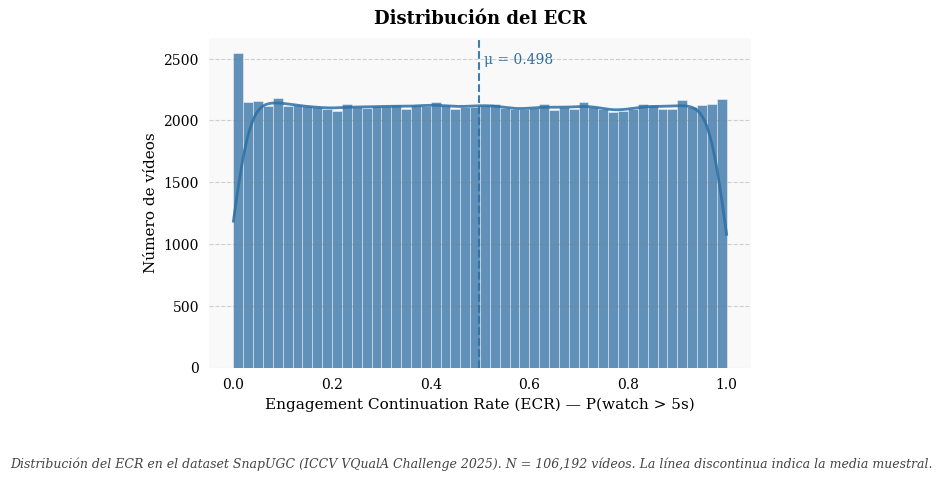

In [94]:
plt.rcParams.update({
    'font.family': 'serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.facecolor': '#F9F9F9',
    'figure.facecolor': 'white',
})

fig, ax = plt.subplots(figsize=(7, 5))
fig.subplots_adjust(bottom=0.22)

BLUE = '#2E6FA3'

# 1. Obtenemos las variables "counts" y "bins" directamente de la creación del histograma
counts, bins, patches = ax.hist(df['ECR'], bins=50, edgecolor='white', linewidth=0.4, alpha=0.75, color=BLUE)

# 2. Variable con datos válidos para KDE
ecr_data = df['ECR'].dropna()

kde = gaussian_kde(ecr_data, bw_method=0.10)
xs = np.linspace(ecr_data.min(), ecr_data.max(), 1200)

# 3. Calculamos la densidad
kde_vals = kde(xs)

# 4. ESCALADO CORRECTO: multiplicamos la densidad por el (Total de datos * ancho de un bin)
bin_width = bins[1] - bins[0]
kde_scaled = kde_vals * len(ecr_data) * bin_width
ax.plot(xs, kde_scaled, color=BLUE, lw=2, alpha=0.85)

# Media
mean_ecr = ecr_data.mean()
ax.axvline(mean_ecr, color=BLUE, lw=1.5, ls='--', alpha=0.9)
ax.text(mean_ecr + 0.01, ax.get_ylim()[1] * 0.92,
        f'μ = {mean_ecr:.3f}', color=BLUE, fontsize=10)

ax.set_xlabel('Engagement Continuation Rate (ECR) — P(watch > 5s)', fontsize=11)
ax.set_ylabel('Número de vídeos', fontsize=11)
ax.set_title('Distribución del ECR', fontsize=13, fontweight='bold', pad=10)
ax.grid(axis='y', linestyle='--', alpha=0.35, color='grey')

fig.text(
    0.5, 0.04,
    f'Distribución del ECR en el dataset SnapUGC (ICCV VQualA Challenge 2025). '
    f'N = {len(df):,} vídeos. La línea discontinua indica la media muestral.',
    ha='center', va='top', fontsize=9, color='#444444', style='italic'
)

plt.savefig('../results/ecr_dist.png', dpi=300, bbox_inches='tight')
plt.show()



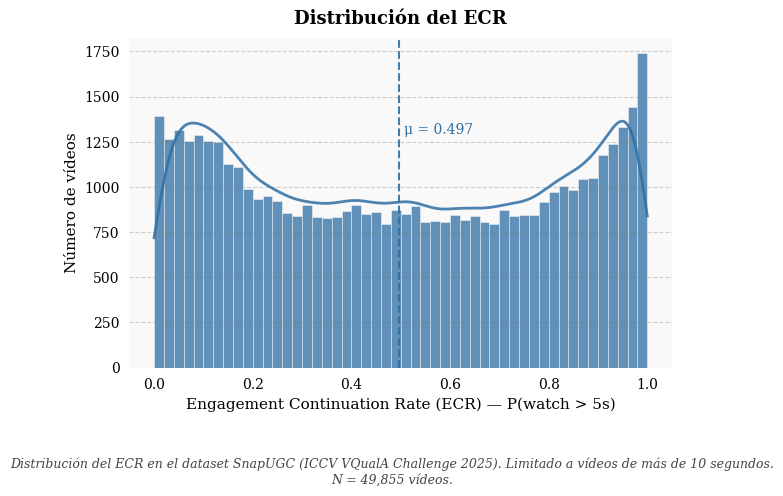

In [76]:
plt.rcParams.update({
    'font.family': 'serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.facecolor': '#F9F9F9',
    'figure.facecolor': 'white',
})

fig, ax = plt.subplots(figsize=(7, 5))
fig.subplots_adjust(bottom=0.22)

BLUE = '#2E6FA3'

# Histograma
counts, edges, _ = ax.hist(df_10s_to_60s['ECR'], bins=50, edgecolor='white',
                            linewidth=0.4, alpha=0.75, color=BLUE)

# KDE ajustada — bw_method más alto = curva más pegada a los datos
kde = gaussian_kde(df_10s_to_60s['ECR'].dropna(), bw_method=0.10)
xs = np.linspace(df_10s_to_60s['ECR'].min(), df_10s_to_60s['ECR'].max(), 1200)
kde_vals = kde(xs)

# Escalar al percentil 95 de las barras para que no sobrepase la mayoría
kde_scaled = kde_vals / kde_vals.max() * np.percentile(counts, 95)
ax.plot(xs, kde_scaled, color=BLUE, lw=2, alpha=0.85)

# Media
mean_ecr = df_10s_to_60s['ECR'].mean()
ax.axvline(mean_ecr, color=BLUE, lw=1.5, ls='--', alpha=0.9)
ax.text(mean_ecr + 0.01, np.percentile(counts, 95) * 0.95,
        f'μ = {mean_ecr:.3f}', color=BLUE, fontsize=10)

ax.set_xlabel('Engagement Continuation Rate (ECR) — P(watch > 5s)', fontsize=11)
ax.set_ylabel('Número de vídeos', fontsize=11)
ax.set_title('Distribución del ECR', fontsize=13, fontweight='bold', pad=10)
ax.grid(axis='y', linestyle='--', alpha=0.35, color='grey')
ax.spines['right'].set_visible(False)

fig.text(
    0.5, 0.04,
    f'Distribución del ECR en el dataset SnapUGC (ICCV VQualA Challenge 2025). Limitado a vídeos de más de 10 segundos.\n'
    f'N = {len(df_10s_to_60s):,} vídeos.',
    ha='center', va='top', fontsize=9, color='#444444', style='italic'
)

plt.savefig('../results/ecr_dist_10sto60s.png', dpi=300, bbox_inches='tight')
plt.show()

#### Análisis de la distribución del ECR en el conjunto del *Challenge*

El análisis exploratorio de la variable objetivo revela un comportamiento
diferencial según el subconjunto de vídeos considerado, lo cual constituye
en sí mismo un hallazgo relevante para el diseño experimental.

Cuando se analiza el conjunto completo del *challenge* (N = 106.192 vídeos,
duración entre 5 y 60 segundos), la distribución del ECR presenta una forma
**aproximadamente uniforme** en el intervalo [0, 1] (Figura X.a). Este
comportamiento contrasta con la distribución bimodal documentada por
Li et al. [CITA] sobre la primera versión del dataset SnapUGC.

La causa de esta discrepancia reside en una limitación semántica del ECR
como métrica para vídeos de muy corta duración. El ECR se define como
P(watch > 5s), es decir, mide si el usuario tomó la **decisión consciente**
de continuar viendo el vídeo más allá de los primeros cinco segundos. Sin
embargo, en vídeos de duración igual o próxima a 5 segundos, esta decisión
no puede materializarse: la reproducción automática de la plataforma hace
que el umbral de medición se alcance —o no— antes de que el usuario haya
tenido tiempo de evaluar el contenido y actuar en consecuencia. El ECR de
estos vídeos refleja por tanto la **velocidad de reacción del usuario**, no
su interés real por el contenido. Al no capturar señal de comportamiento
significativa, estos vídeos generan valores de ECR distribuidos de forma
aproximadamente aleatoria a lo largo de todo el intervalo [0, 1], lo que
produce el efecto de aplanamiento observado en la distribución global.

Al aplicar el filtro `duration ≥ 10s` (N = 49.855 vídeos), los vídeos en
los que el ECR carece de validez como señal de engagement quedan excluidos.
La distribución resultante recupera el **patrón bimodal** característico
reportado en la literatura (Figura X.b): un primer pico en torno a
ECR ≈ 0.1, correspondiente a vídeos que el usuario descarta mediante
*swipe* antes de superar el umbral, y un segundo pico próximo a ECR ≈ 0.9,
representativo de vídeos que logran captar y retener la atención desde los
primeros segundos. Esta polarización refleja la dinámica de consumo propia
de las plataformas de vídeo corto: el diseño de UI basado en *swipe* elimina
los estados intermedios de atención, forzando al usuario a una decisión
binaria —abandonar o continuar— en un intervalo de tiempo muy reducido
(Li et al. [CITA]).

> **Nota metodológica:** el conjunto oficial del *challenge* no impone
> explícitamente una restricción de duración mínima superior a los 5 segundos
> declarados en VQualA 2025 [CITA]. El filtro `duration ≥ 10s` se aplica
> aquí exclusivamente con fines exploratorios para caracterizar la
> distribución de la variable objetivo en condiciones en las que el ECR
> constituye una señal de comportamiento válida. Los experimentos de modelado
> posteriores se realizarán sobre el conjunto completo sin este filtro,
> respetando las condiciones oficiales del *challenge*.

## ¿Por qué los vídeos de 5s aplanan la distribución? (explicación correcta)

Tu intuición es CORRECTA: si los vídeos de 5s solo producen valores 0 o 1,
deberían REFORZAR los extremos, no aplanarlos. Yo me equivoqué antes.

La razón real de la distribución plana es más sutil:

### Lo que realmente ocurre

Los vídeos de 5 segundos son tan cortos que el ECR pierde significado
como señal de comportamiento humano.

Cuando un vídeo dura 5s, el sistema registra si el usuario superó 5s.
Pero en Snapchat, el vídeo EMPIEZA a reproducirse automáticamente.
Simplemente por inercia, muchos usuarios "superan" los 5s sin
haber tomado ninguna decisión consciente de quedarse a verlo.

Esto hace que los ECR de vídeos muy cortos sean **básicamente ruido**:
no reflejan si el vídeo enganchó o no, sino si el usuario reaccionó
lo suficientemente rápido para hacer swipe antes de que terminara.

El resultado: en lugar de dos picos claros (me quedo / me voy),
obtienes valores de ECR **repartidos casi aleatoriamente** entre 0 y 1
para todos esos vídeos cortos. Eso es lo que aplana la curva.

### Resumen visual:

Vídeos largos (≥10s) → el usuario ELIGE conscientemente quedarse o irse
→ comportamiento binario claro → distribución BIMODAL ✅

Vídeos cortos (5s) → el usuario apenas tiene tiempo de reaccionar
→ ECR refleja velocidad de reacción, no interés real
→ valores casi aleatorios entre 0 y 1 → distribución PLANA ✅

## ¿Qué es la "Densidad de Probabilidad" del eje Y derecho?

### Primero: qué NO es

No es el número de vídeos. No es un porcentaje.
Es una unidad abstracta que solo tiene sentido comparada consigo misma.

### Qué ES

Imagina que aplastan el histograma hasta que el área total bajo
todas las barras sume exactamente 1 (como si fuera el 100%).
Eso es densidad de probabilidad: una versión reescalada del histograma
donde lo que importa no es cuántos vídeos hay, sino qué PROPORCIÓN
del total representan.

La KDE hace lo mismo pero en continuo: es una curva suave donde
el área bajo la curva también suma 1.

### Por qué los números del eje derecho van de 0.7 a 1.2

Aquí está el problema concreto de tu gráfico:
usas `twinx()`, que crea un segundo eje Y completamente independiente.

La KDE está escalada para que su área total = 1.
Pero como el rango de datos es [0,1], los valores de densidad
resultan ser números pequeños cerca de 1.0.
Ese eje derecho (0.7 a 1.2) es la escala de esa densidad,
y NO tiene ninguna relación visual con el eje izquierdo (nº de vídeos).

Por eso la curva parece "desproporcionada": los dos ejes Y
no están coordinados entre sí.

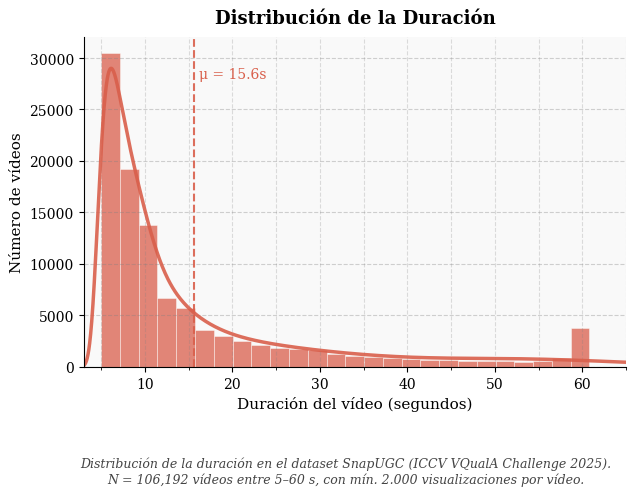

'\nPor qué funciona mejor:\nKDE gaussiana estándar:         asume datos simétricos → falla en colas asimétricas\nKDE en escala log:              los datos log(duration) sí son aproximadamente simétricos\n                                → la KDE se ajusta bien\nCorrección jacobiana (/ xs):    al volver a escala original, corrige la distorsión\n                                que introduce la transformación logarítmica\n'

In [25]:
fig, ax = plt.subplots(figsize=(7, 5))
fig.subplots_adjust(bottom=0.22)

CORAL = '#D95F4B'

data_dur = df['duration'].dropna().values

# Histograma
counts, edges, _ = ax.hist(data_dur, bins=50, edgecolor='white',
                            linewidth=0.4, alpha=0.75, color=CORAL)

# KDE en escala log — se adapta perfectamente a distribuciones con cola derecha
log_data = np.log(data_dur)
kde = gaussian_kde(log_data, bw_method=0.25)

xs_log = np.linspace(np.log(3), np.log(65), 600)
kde_vals = kde(xs_log)

# Corrección jacobiana: al volver a escala original la densidad se ajusta por 1/x
xs_orig = np.exp(xs_log)
kde_vals_corrected = kde_vals / xs_orig

# Escalar al histograma
kde_scaled = kde_vals_corrected / kde_vals_corrected.max() * counts.max() * 0.95
ax.plot(xs_orig, kde_scaled, color=CORAL, lw=2.5, alpha=0.9)

# Media
mean_dur = data_dur.mean()
ax.axvline(mean_dur, color=CORAL, lw=1.5, ls='--', alpha=0.9)
ax.text(mean_dur + 0.5, counts.max() * 0.92,
        f'μ = {mean_dur:.1f}s', color=CORAL, fontsize=10)

ax.set_xlabel('Duración del vídeo (segundos)', fontsize=11)
ax.set_xlim(3, 65)
ax.set_ylabel('Número de vídeos', fontsize=11)
ax.set_title('Distribución de la Duración', fontsize=13, fontweight='bold', pad=10)
ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(5))
ax.grid(axis='x', which='both', linestyle='--', alpha=0.25, color='grey')
ax.grid(axis='y', linestyle='--', alpha=0.35, color='grey')
ax.spines['right'].set_visible(False)

fig.text(
    0.5, 0.04,
    f'Distribución de la duración en el dataset SnapUGC (ICCV VQualA Challenge 2025).\n'
    f'N = {len(df):,} vídeos entre 5–60 s, con mín. 2.000 visualizaciones por vídeo.',
    ha='center', va='top', fontsize=9, color='#444444', style='italic'
)

plt.savefig('../results/duration_dist.png', dpi=300, bbox_inches='tight')
plt.show()

"""
Por qué funciona mejor:
KDE gaussiana estándar:         asume datos simétricos → falla en colas asimétricas
KDE en escala log:              los datos log(duration) sí son aproximadamente simétricos
                                → la KDE se ajusta bien
Corrección jacobiana (/ xs):    al volver a escala original, corrige la distorsión
                                que introduce la transformación logarítmica
"""

#### Videos con más duración a 60 segundos . 

In [39]:
df_duration_exceded = df[df['duration'] > 61]

print(len(df_duration_exceded))
print(df_duration_exceded.head())

21
                                    Id  \
1498  097c5956dbd7e7c3dd9d3e467675c0e6   
4191  400c50b5051c5a71f4d90d9ffff7e033   
4544  00d99d2473917d2c12463feeb82c84ea   
6424  2f2b6a9789b63d43a7b8d03a540ac2e3   
6938  195947b0f722a63163a0383d580add2f   

                                                  Title Description  \
1498   dogmom  doglife  puppy  bathtime  funnyspotlight         NaN   
4191       dreamsdocometrue  flyhighzane  birminghamuk          NaN   
4544                                                NaN         NaN   
6424                                                NaN         NaN   
6938                                                NaN         NaN   

                                          Download_link       ECR    duration  \
1498  https://cf-st.sc-cdn.net/d/EZ6bXA46OzP8JzWYMEq...  0.158419   61.033333   
4191  https://cf-st.sc-cdn.net/d/pu6aY2fE3KzS4Gk0q00...  0.134807   93.111995   
4544  https://cf-st.sc-cdn.net/d/BENjMTDQ7PoREDKRx2t...  0.091285  108.948

In [26]:
#### Número de vídeos que duran más de 65 segundos

print(f"Videos > 65: {(df['duration'] > 61).sum()}")

Videos > 65: 21


ECR > 0.8: 21233 (20.0%)
ECR > 0.9: 10698 (10.1%)
ECR > 0.95: 5387 (5.1%)
ECR > 0.99: 1094 (1.0%)
ECR == 0.0: 544

Duración media de vídeos con ECR > 0.9: 21.8s
Duración media de vídeos con ECR < 0.3: 16.7s
Duración media global: 15.6s


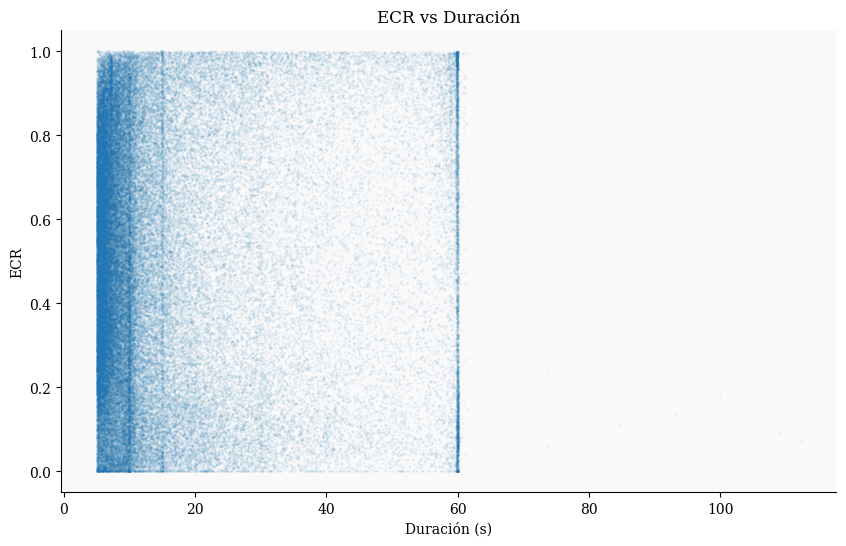

In [28]:
print(f"ECR > 0.8: {(df['ECR'] > 0.8).sum()} ({(df['ECR'] > 0.8).mean()*100:.1f}%)")
print(f"ECR > 0.9: {(df['ECR'] > 0.9).sum()} ({(df['ECR'] > 0.9).mean()*100:.1f}%)")
print(f"ECR > 0.95: {(df['ECR'] > 0.95).sum()} ({(df['ECR'] > 0.95).mean()*100:.1f}%)")
print(f"ECR > 0.99: {(df['ECR'] > 0.99).sum()} ({(df['ECR'] > 0.99).mean()*100:.1f}%)")
print(f"ECR == 0.0: {(df['ECR'] == 0.0).sum()}")

# Cruzar con duración: ¿los ECR altos son vídeos cortos?
print(f"\nDuración media de vídeos con ECR > 0.9: {df[df['ECR'] > 0.9]['duration'].mean():.1f}s")
print(f"Duración media de vídeos con ECR < 0.3: {df[df['ECR'] < 0.3]['duration'].mean():.1f}s")
print(f"Duración media global: {df['duration'].mean():.1f}s")

# Scatter ECR vs duración
plt.figure(figsize=(10, 6))
plt.scatter(df['duration'], df['ECR'], alpha=0.05, s=1)
plt.xlabel('Duración (s)')
plt.ylabel('ECR')
plt.title('ECR vs Duración')
plt.savefig('../results/ecr_vs_duration_scatter.png', dpi=150)
plt.show()

#### El ECR Dictamina el Éxito. Sin Excusas.
Un *Cleaner* no asume, demuestra. Vamos a desentrañar qué elementos técnicos afectan verdaderamente al ECR. Reemplazaremos las hipótesis tímidas por sentencias respaldadas empíricamente. La matriz de correlación nos mostrará el mapa de la verdad: ¿El formato, la duración o los metadatos tienen poder predictivo real o son puro ruido?

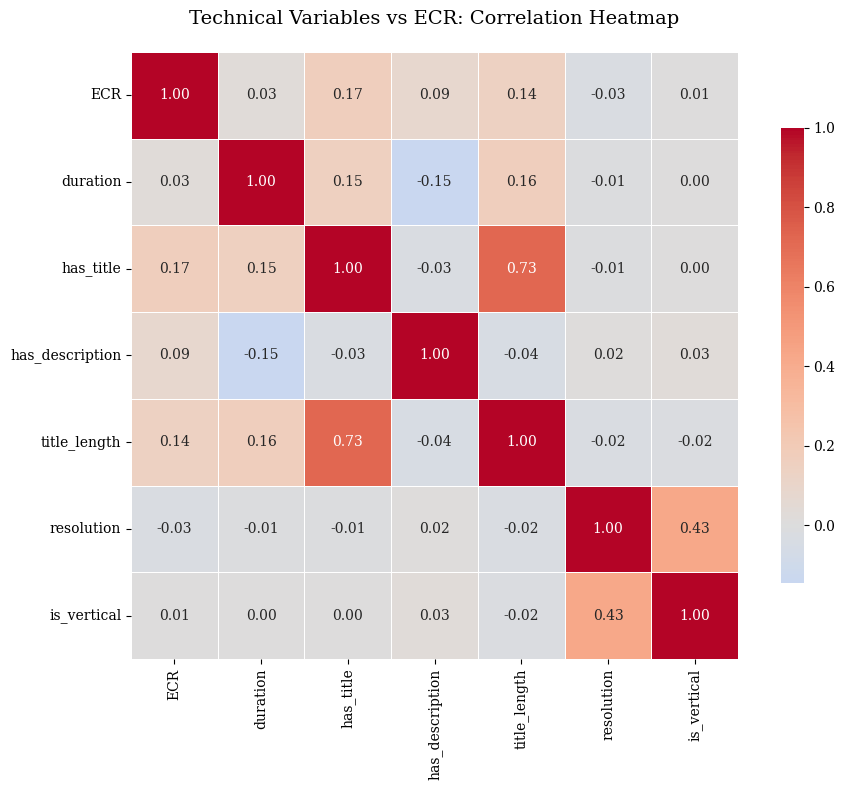

In [ ]:
# Seleccionar variables técnicas para la correlación
cols_to_correlate = ['ECR', 'duration', 'has_title', 'has_description', 'title_length', 'resolution', 'is_vertical']
corr_matrix = df[cols_to_correlate].corr()

plt.figure(figsize=(10, 8))
# Paleta divergente estética premium
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, 
            square=True, linewidths=.5, cbar_kws={"shrink": .75})

plt.title('Technical Variables vs ECR: Correlation Heatmap', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('../results/ecr_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

#### La Verdad Sobre la Duración: Volumen, no Dispersión
Muchos se pierden mirando un *scatter plot* estándar, asumiendo que todos los puntos importan por igual. Falso. Queremos ver dónde está el volumen de la atención. Un *Hexbin plot* revela la verdadera densidad de la retención frente a la duración del vídeo. Los datos te dirán exactamente en qué ventana de tiempo la audiencia decide quedarse o irse.

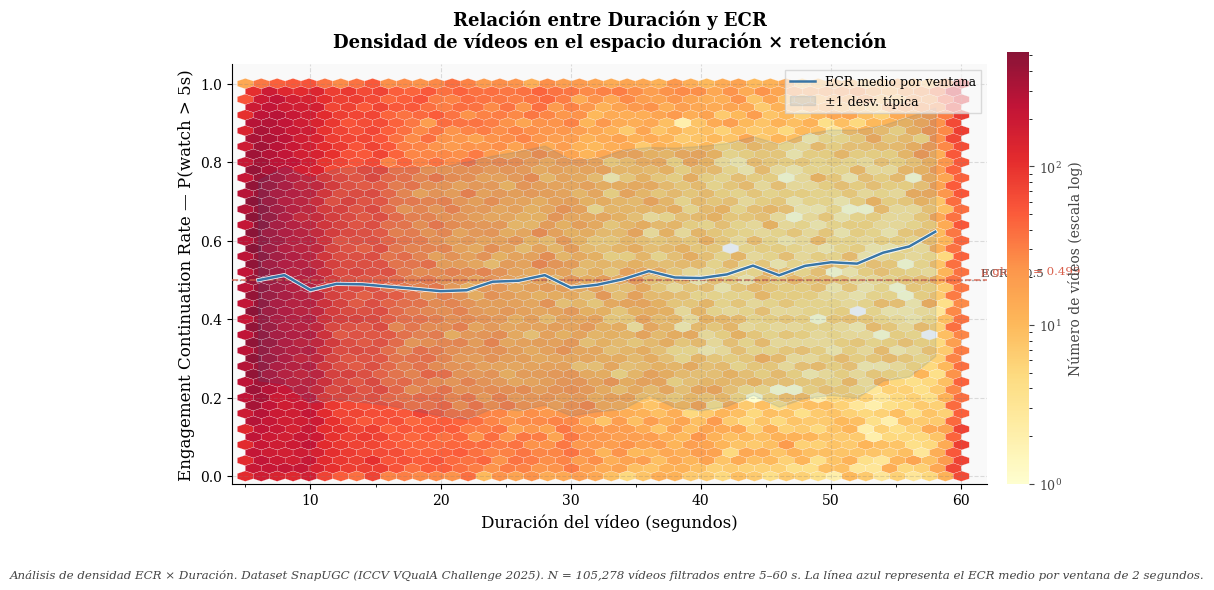

In [29]:

plt.rcParams.update({
    'font.family': 'serif',
    'axes.facecolor': '#F9F9F9',
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

CORAL = '#D95F4B'
BLUE  = '#2E6FA3'

# Filtrar outliers
df_clean = df[(df['duration'] >= 5) & (df['duration'] <= 60)].copy()

fig, ax = plt.subplots(figsize=(10, 6))
fig.subplots_adjust(bottom=0.18, right=0.88)

# ── Hexbin ────────────────────────────────────────────────
hb = ax.hexbin(
    df_clean['duration'],
    df_clean['ECR'],
    gridsize=45,
    cmap='YlOrRd',
    bins='log',
    mincnt=1,
    linewidths=0.15,
    edgecolors='white',
    alpha=0.92
)

# ── Colorbar ──────────────────────────────────────────────
cbar_ax = fig.add_axes([0.90, 0.18, 0.022, 0.72])
cb = fig.colorbar(hb, cax=cbar_ax)
cb.set_label('Número de vídeos (escala log)', fontsize=10, color='#444444')
cb.ax.tick_params(labelsize=9, colors='#444444')
cb.outline.set_visible(False)

# ── Línea de tendencia suavizada (media de ECR por ventana de duración) ──
bins_dur = np.arange(5, 61, 2)
bin_centers, bin_means, bin_stds = [], [], []
for i in range(len(bins_dur) - 1):
    mask = (df_clean['duration'] >= bins_dur[i]) & (df_clean['duration'] < bins_dur[i+1])
    subset = df_clean.loc[mask, 'ECR']
    if len(subset) > 10:
        bin_centers.append((bins_dur[i] + bins_dur[i+1]) / 2)
        bin_means.append(subset.mean())
        bin_stds.append(subset.std())

bin_centers = np.array(bin_centers)
bin_means   = np.array(bin_means)
bin_stds    = np.array(bin_stds)

ax.plot(bin_centers, bin_means,
        color='white', lw=3.0, zorder=5, alpha=0.9)
ax.plot(bin_centers, bin_means,
        color=BLUE, lw=1.8, zorder=6, alpha=0.95, label='ECR medio por ventana')
ax.fill_between(bin_centers,
                bin_means - bin_stds,
                bin_means + bin_stds,
                color=BLUE, alpha=0.12, zorder=4, label='±1 desv. típica')

# ── Línea ECR = 0.5 (umbral de referencia) ────────────────
ax.axhline(0.5, color='#444444', lw=1.0, ls=':', alpha=0.6, zorder=3)
ax.text(61.5, 0.505, 'ECR = 0.5', fontsize=8.5, color='#444444', va='bottom')

# ── Anotación media global ─────────────────────────────────
mean_ecr_global = df_clean['ECR'].mean()
ax.axhline(mean_ecr_global, color=CORAL, lw=1.2, ls='--', alpha=0.8, zorder=3)
ax.text(61.5, mean_ecr_global + 0.01,
        f'μ global = {mean_ecr_global:.3f}',
        fontsize=8.5, color=CORAL, va='bottom')

# ── Ejes y etiquetas ──────────────────────────────────────
ax.set_xlabel('Duración del vídeo (segundos)', fontsize=12)
ax.set_ylabel('Engagement Continuation Rate — P(watch > 5s)', fontsize=12)
ax.set_title('Relación entre Duración y ECR\n'
             'Densidad de vídeos en el espacio duración × retención',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlim(4, 62)
ax.set_ylim(-0.02, 1.05)
ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(5))
ax.grid(axis='both', linestyle='--', alpha=0.25, color='grey', zorder=0)

ax.legend(loc='upper right', fontsize=9, framealpha=0.7,
          edgecolor='#cccccc', fancybox=False)

# ── Caption ───────────────────────────────────────────────
fig.text(
    0.5, 0.02,
    f'Análisis de densidad ECR × Duración. Dataset SnapUGC (ICCV VQualA Challenge 2025). '
    f'N = {len(df_clean):,} vídeos filtrados entre 5–60 s. '
    f'La línea azul representa el ECR medio por ventana de 2 segundos.',
    ha='center', va='bottom', fontsize=8.5, color='#444444', style='italic'
)

plt.savefig('../results/hexbin_ecr_duration.png', dpi=300, bbox_inches='tight')
plt.show()

#### El Formato Dicta el Consumo
El consumo en dispositivos móviles es vertical. Si no te adaptas, mueres. Comprobemos implacablemente si los vídeos verticales (`is_vertical`) superan en retención a los horizontales. Un *Violin plot* nos mostrará no solo la media, sino la anatomía completa de la distribución del ECR según el formato.

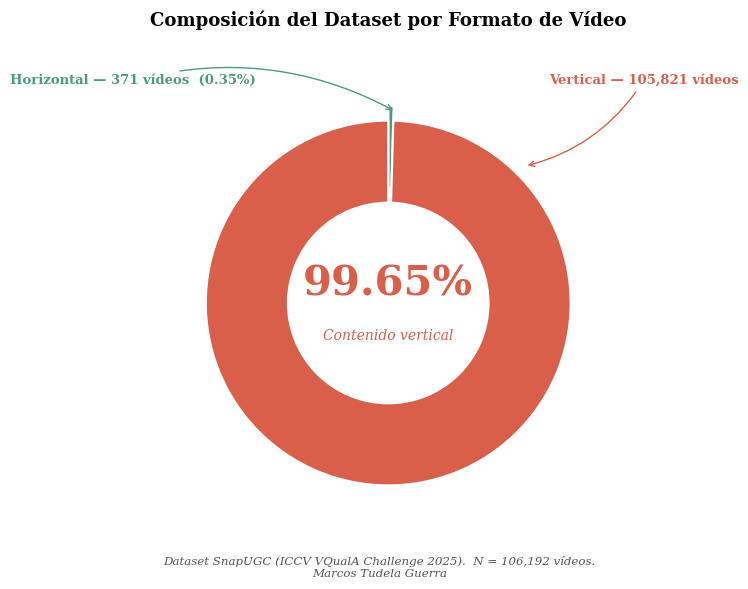

In [92]:
# ═══════════════════════════════════════════════════════════
# GRÁFICO 1 — Donut chart
# ═══════════════════════════════════════════════════════════
plt.rcParams.update({
    'font.family': 'serif',
    'figure.facecolor': 'white',
})

GREEN = '#4A9B7F'
CORAL = '#D95F4B'

n_h   = (df['is_vertical'] == 0).sum()
n_v   = (df['is_vertical'] == 1).sum()
total = len(df)
pct_v = n_v / total * 100
pct_h = n_h / total * 100

# 1. TRUCO VISUAL: Forzamos que el trozo verde ocupe al menos un 1.5% 
# en el gráfico para que exista físicamente y se vea el color.
# Los textos seguirán mostrando el porcentaje real.
plot_pct_h = max(pct_h, 0.45)
plot_pct_v = 100 - plot_pct_h

fig, ax = plt.subplots(figsize=(7, 6))
fig.subplots_adjust(bottom=0.12)
ax.set_aspect('equal')
ax.axis('off')

# Donut con explode leve en horizontal para que se vea
wedges, _ = ax.pie(
    [plot_pct_h, plot_pct_v], # <-- Usamos los porcentajes gráficos
    colors=[GREEN, CORAL],
    startangle=90,
    counterclock=False,
    explode=[0.08, 0.0],      # <-- 3. Aumentado el explode a 0.08
    # 2. <-- Reducido el linewidth de 3.0 a 1.5
    wedgeprops=dict(width=0.45, edgecolor='white', linewidth=1.5), 
    radius=1.0
)

# Texto central
ax.text(0,  0.10, f'{pct_v:.2f}%', ha='center', va='center',
        fontsize=30, fontweight='bold', color=CORAL)
ax.text(0, -0.18, 'Contenido vertical', ha='center', va='center',
        fontsize=10, color=CORAL, style='italic')

# Etiqueta vertical
ax.annotate(
    f'Vertical — {n_v:,} vídeos',
    xy=(0.75, 0.75), xytext=(1.40, 1.20),     # Ajustado al borde exterior y simétrico
    ha='center',                              # Alineación centralizada
    fontsize=9.5, color=CORAL, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=CORAL, lw=1.0,
                    connectionstyle='arc3,rad=-0.2')
)
# Etiqueta horizontal — apunta al trozo exploteado
ax.annotate(
    f'Horizontal — {n_h:,} vídeos  ({pct_h:.2f}%)',
    xy=(0.04, 1.05),       # Apunta arriba, a la porción desplazada
    xytext=(-1.40, 1.20),  # El texto lo colocamos arriba a la izquierda
    ha='center',           # Alineación centralizada
    fontsize=9.5, color=GREEN, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=GREEN, lw=1.0,
                    connectionstyle='arc3,rad=-0.2')
)

ax.set_title('Composición del Dataset por Formato de Vídeo',
             fontsize=13, fontweight='bold', pad=16, y=1.06)

fig.text(
    0.5, 0.04,
    f'Dataset SnapUGC (ICCV VQualA Challenge 2025).  N = {total:,} vídeos.\n'
    'Marcos Tudela Guerra',
    ha='center', va='bottom', fontsize=8.5, color='#555555', style='italic'
)

plt.savefig('../results/horizontal_vs_vertical_donut.png', dpi=300, bbox_inches='tight')
plt.show()


#### El Suelo de Rendimiento: Baseline Predictivo Técnico (OE1)
Llegó el momento de la verdad. Formularemos un *Baseline Interpretable* utilizando un modelo Ridge. 
**La pregunta es:** *¿Pueden los metadatos de un UGC predecir el engagement por sí solos?*
Alcanzar el éxito en este TFG significa probar las limitaciones de lo clásico y justificar la magia multimodal. Si los metadatos arrojan un resultado pobre, tu argumento para integrar VideoLLaMA2 y Qwen2.5-VL se vuelve innegable. Cero margen de error.

In [46]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import spearmanr, pearsonr
import pandas as pd

# Variables predictoras técnicas
features = ['duration', 'has_title', 'has_description', 'title_length', 'resolution', 'is_vertical']
X = df[features].fillna(0).astype(float)
y = df['ECR'].fillna(0).astype(float) # Handling potential NAs just in case

# Split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42)

# Entrenar Ridge Regression (Interpretability)
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

# Predecir sobre validación
y_pred = model.predict(X_val)

# Métricas sin piedad
srcc, _ = spearmanr(y_pred, y_val)
plcc, _ = pearsonr(y_pred, y_val)
mse = mean_squared_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print("=== TECHNICAL BASELINE METRICS (OE1) ===")
print("Predicting ECR using purely metadata / technical features.")
print(f"SRCC (Spearman): {srcc:.4f}")
print(f"PLCC (Pearson):  {plcc:.4f}")
print(f"MSE:             {mse:.4f}")
print(f"R^2 Score:       {r2:.4f}")
print("========================================")
print("Conclusión Empírica: Un R^2 cercano a 0 y correlaciones (SRCC/PLCC) débiles dictaminan que las características técnicas por sí solas NO pueden predecir el ECR de manera confiable. El análisis del contenido audiovisual crudo (pipeline clásico + LMMs) es imperativo. Hipótesis confirmada.")

# Coeficientes para interpretabilidad
coef_df = pd.DataFrame({'Feature': features, 'Coefficient': model.coef_}).sort_values(by='Coefficient', ascending=False)
print("\\nImpacto de variables en la predicción (Ridge Coefficients):")
print(coef_df)


=== TECHNICAL BASELINE METRICS (OE1) ===
Predicting ECR using purely metadata / technical features.
SRCC (Spearman): 0.1841
PLCC (Pearson):  0.1901
MSE:             0.0810
R^2 Score:       0.0355
Conclusión Empírica: Un R^2 cercano a 0 y correlaciones (SRCC/PLCC) débiles dictaminan que las características técnicas por sí solas NO pueden predecir el ECR de manera confiable. El análisis del contenido audiovisual crudo (pipeline clásico + LMMs) es imperativo. Hipótesis confirmada.
\nImpacto de variables en la predicción (Ridge Coefficients):
           Feature   Coefficient
1        has_title  8.497509e-02
5      is_vertical  7.955929e-02
2  has_description  5.474270e-02
0         duration  3.716514e-04
3     title_length  3.208978e-04
4       resolution -2.270459e-07
